In [10]:
import sys
from pathlib import Path

# Ensure project root is on sys.path so local modules (common, etc.) can be imported
_project_root = str(
    next(
        (
            _p
            for _p in (Path.cwd(), *Path.cwd().parents)
            if (_p / "common.py").is_file()
        ),
        Path.cwd().parent,
    )
)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)


import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1c"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)
df["N_features"] = df["features"].str.extract(r"(?:HVG)?RFE_(\d+)_permute")
# For MOSA, "all" means all 200 latent dimensions
df.loc[(df["context"] == "MOSA") & (df["features"] == "all"), "N_features"] = "200"
df["selection_method"] = df["features"].str.extract(r"(HVGRFE|RFE)_\d+_permute")
# For MOSA, "all" means all RFE
df.loc[(df["context"] == "MOSA") & (df["features"] == "all"), "selection_method"] = "RFE"

In [11]:
val_df = df[df.dataset == "val"]
dmm_val_df = val_df[val_df.ref == "DMM"]
dmm_val_df = dmm_val_df[dmm_val_df.features.str.contains("RFE") | (dmm_val_df.features == "all")]
dmm_val_df = dmm_val_df.dropna(subset=["N_features"]).copy()
dmm_val_df["N_features"] = dmm_val_df["N_features"].astype("int")
dmm_val_df = dmm_val_df.groupby(
    ["context", "features", "N_features", "model", "samples", "selection_method"]
).rmse.median().reset_index()


In [12]:
# Show MOSA rows after filtering
display(dmm_val_df[(dmm_val_df.context == "MOSA") & (dmm_val_df.features == "all")])


,context,features,N_features,model,samples,selection_method,rmse
36,MOSA,all,200,EGFR_MAPK__logobs,BT20,RFE,0.569668
37,MOSA,all,200,EGFR_MAPK__logobs,HCC1500,RFE,0.619693
38,MOSA,all,200,EGFR_MAPK__logobs,MCF7,RFE,0.733010


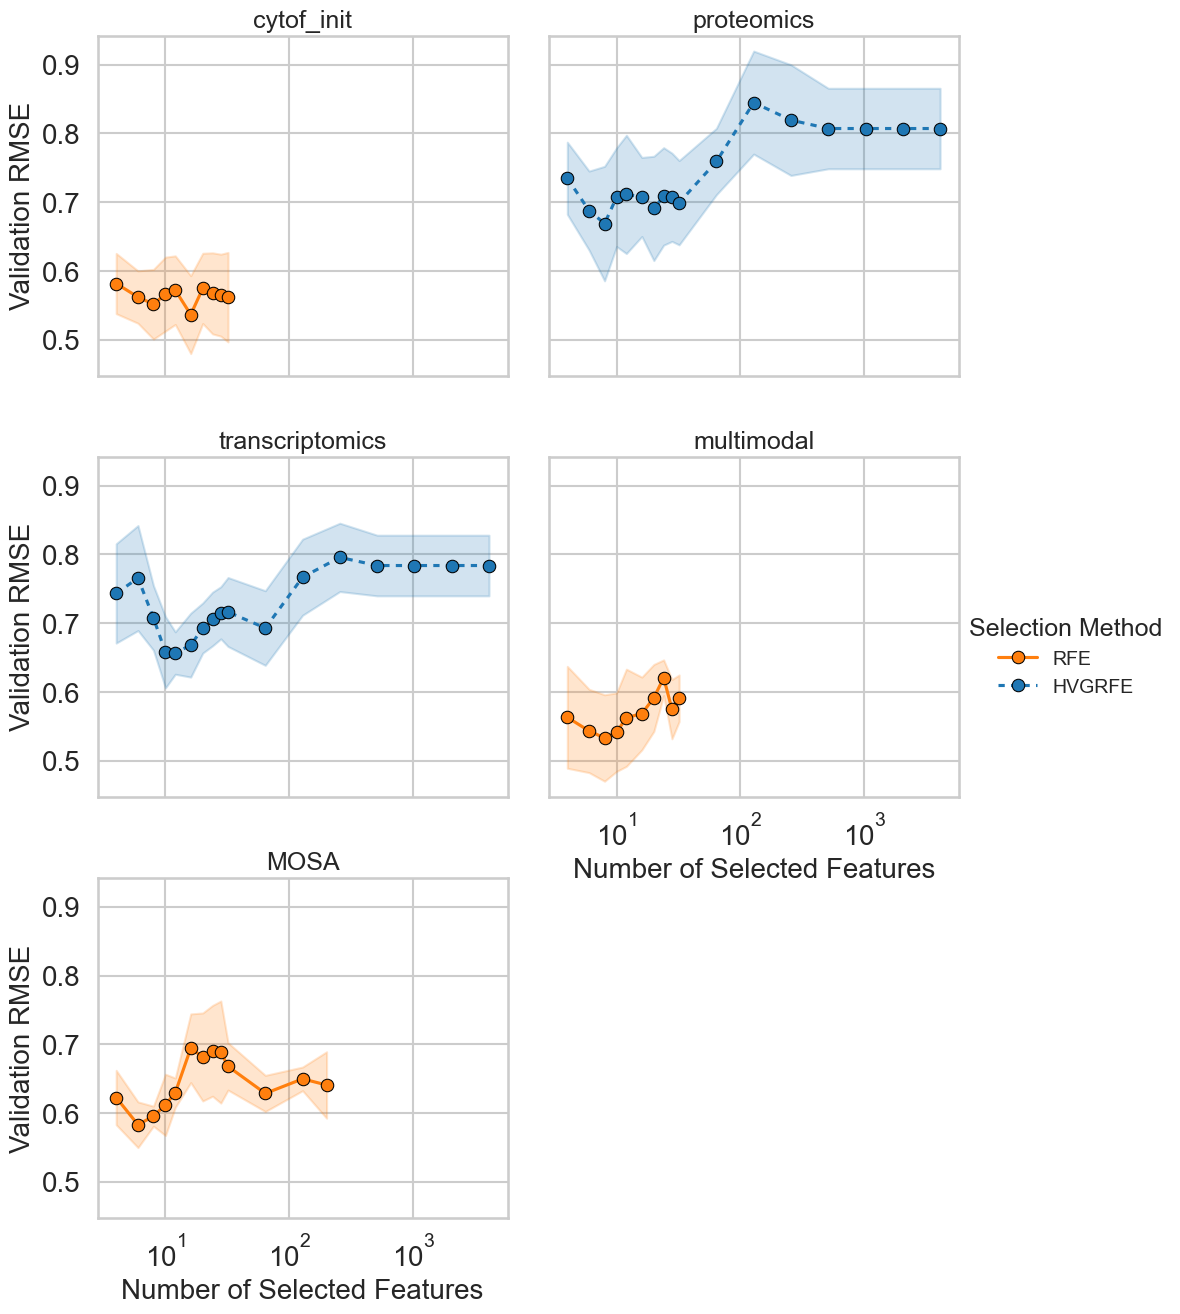

In [13]:
import matplotlib.pyplot as plt
# Set a modern style
sns.set_theme(style="whitegrid", context="talk")

palette = {
    "cytof_init": "cyan",
    "proteomics": "gold",
    "transcriptomics": "green",
    "multimodal": "coral",
    "MOSA": "purple",
}

g = sns.FacetGrid(
    dmm_val_df,
    col="context",
    col_order=palette.keys(),
    col_wrap=2,
    sharey=True,
    despine=False,
    height=5,
)

g.map_dataframe(
    sns.lineplot,
    x="N_features",
    y="rmse",
    marker='o',
    hue="selection_method",
    style="selection_method",
    palette={"HVGRFE": "tab:blue", "RFE": "tab:orange"},
    dashes={"HVGRFE": (2, 2), "RFE": ""},
    mec="black",
    estimator='mean',
    errorbar="se",
)

# Set x-axis to logarithmic scale
for ax in g.axes.flatten():
    ax.set_xscale("log")

# Add axis labels and titles
g.set_axis_labels("Number of Selected Features", "Validation RMSE", fontsize=20)
g.set_titles(col_template="{col_name}", fontsize=20)

# Enlarge tick labels
for ax in g.axes.flatten():
    ax.tick_params(axis='both', which='major', labelsize=20)

# Add legend
g.add_legend(title="Selection Method", fontsize=14, title_fontsize=16)

# Adjust layout
plt.subplots_adjust(top=0.85, wspace=0.10)
plt.show()

In [14]:
dmm_val_df[dmm_val_df.context == "cytof_init"].groupby("features").rmse.mean().sort_values()

features
RFE_16_permute    0.536397
RFE_8_permute     0.551512
RFE_32_permute    0.561774
RFE_6_permute     0.561943
RFE_28_permute    0.564671
RFE_10_permute    0.566261
RFE_24_permute    0.567308
RFE_12_permute    0.571974
RFE_20_permute    0.574538
RFE_4_permute     0.581643
Name: rmse, dtype: float64

In [15]:
dmm_val_df[dmm_val_df.context == "multimodal"].groupby("features").rmse.mean().sort_values()

features
RFE_8_permute     0.533062
RFE_10_permute    0.541491
RFE_6_permute     0.543289
RFE_12_permute    0.562500
RFE_4_permute     0.563150
RFE_16_permute    0.568672
RFE_28_permute    0.574942
RFE_32_permute    0.590873
RFE_20_permute    0.591340
RFE_24_permute    0.620724
Name: rmse, dtype: float64

In [16]:
dmm_val_df[dmm_val_df.context == "transcriptomics"].groupby("features").rmse.mean().sort_values()

features
HVGRFE_12_permute      0.656636
HVGRFE_10_permute      0.657756
HVGRFE_16_permute      0.668121
HVGRFE_64_permute      0.692997
HVGRFE_20_permute      0.693000
HVGRFE_24_permute      0.706168
HVGRFE_8_permute       0.707640
HVGRFE_28_permute      0.715184
HVGRFE_32_permute      0.716319
HVGRFE_4_permute       0.743326
HVGRFE_6_permute       0.765687
HVGRFE_128_permute     0.766935
HVGRFE_512_permute     0.783917
HVGRFE_1024_permute    0.783917
HVGRFE_2048_permute    0.783917
HVGRFE_4096_permute    0.783917
HVGRFE_256_permute     0.795789
Name: rmse, dtype: float64

In [17]:
dmm_val_df[dmm_val_df.context == "proteomics"].groupby("features").rmse.mean().sort_values()

features
HVGRFE_8_permute       0.668806
HVGRFE_6_permute       0.687701
HVGRFE_20_permute      0.690866
HVGRFE_32_permute      0.699192
HVGRFE_28_permute      0.707100
HVGRFE_10_permute      0.707176
HVGRFE_16_permute      0.707543
HVGRFE_24_permute      0.708354
HVGRFE_12_permute      0.711251
HVGRFE_4_permute       0.734767
HVGRFE_64_permute      0.759130
HVGRFE_512_permute     0.807086
HVGRFE_1024_permute    0.807086
HVGRFE_2048_permute    0.807086
HVGRFE_4096_permute    0.807086
HVGRFE_256_permute     0.819338
HVGRFE_128_permute     0.844810
Name: rmse, dtype: float64

In [18]:
dmm_val_df[dmm_val_df.context == "MOSA"].groupby("features").rmse.mean().sort_values()

features
RFE_6_permute      0.582970
RFE_8_permute      0.595465
RFE_10_permute     0.611882
RFE_4_permute      0.622561
RFE_64_permute     0.628527
RFE_12_permute     0.629589
all                0.640790
RFE_128_permute    0.649720
RFE_32_permute     0.667816
RFE_20_permute     0.681554
RFE_28_permute     0.688695
RFE_24_permute     0.690512
RFE_16_permute     0.694225
Name: rmse, dtype: float64